In [1]:
import networkx as nx 
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox

# Spectral Graph Theory: Finding Structure in Networks 
## Traffic Optimization Using Spectral Graph Theory / 
## Spectral Urban generate models 

## Preparation
1. What to research:
    - eigenvectors(refresh knowledge)
    - clustering algorithms
    - community detection in social networks
    - neural brain networks, transportation system or recommendation systems
    - Laplacian matrix, Adjacency, edge and their connection
    - How to discover the hidden structure inside networks maybe even make some connection to nature/biology
    - add later a relation to a topic that interests you and is a guess-prove type of logic behind it #TO-DO
    - Fiedler value - to show how well connected the network is
    - https://networksciencebook.com/
    - https://math.mit.edu/~spielman/561/
    - https://networkx.org/documentation/stable/ - networkx documentation
    - OSMnx
    - OpenStreetMap
2. What actually is Sprectral Graph Theory?
   - Spectral graph theory starts by associating matrices to graphs, notably,
     the adjacency matrix and the laplacian matrix (see: 'A BRIEF INTRODUCTION TO SPECTRAL GRAPH THEORY'- BOGDAN NICA) /
   - The main objective of spectral graph theory is to relate properties of graphs with the eigenvalues
     and eigenvectors (spectral properties) of associated matrices.(see: 
     'Lecture11: Introduction to Spectral Graph Theory - RajatMittal, IITKanpur)<-
3. Plan
    1. Make a random model(or use a model of the roads of a town/ part of a city like the center of Sofia)
      and with probality and statistics simulate :
        - a random traffic flow
        - congestion probability
        - route usage
    2. Analyze Traffik Bottlenecks
        - Whats a Traffik Bottleneck? - It is a localized disruption of vehicular traffic on a street, road, or highway
        - Whats the difference between a traffik jam and a bottleneck? Bottleneck is a result of a specific physical condition like :
            - design of the road
            - badly timed traffic lights
            - sharp curves
            - temporary situations, such as vehicular accidents.

## Research 

### Terms and Explanations
1. Undirected graph
    - Let's start from 0: A graph is a group of dots connected by lines. The dots could represent things(people, places, math equation results;
       we will refer to them as **nodes**). The lines between these dots are called **edges** (the connections).
    - An undirected graph is a type of graph where the edges have no specified direction assigned to the them.(geeksforgeeks)
    - If we care only if two nodes are connected or not, we call such a graph **unweighted**.
    - For the nodes with an edge between them, we say they are **adjacent** or neighbors of one another.
    - $G = (V, E)$ is a set of vertices $V$ and a set of connections $E \subseteq V \times V$ between these vertices 
    - Its edges are bidirectional
        - To represent that relationship that goes both ways we use sets {}. Example: $\{'Tom', 'Jerry'\}$ 
    - may contain loops(edges that connect a vertex to itself)
    - degree of each edge is the same as the number of edges connected to it
    - One of the ways to represent a graph is with an **edge-list** - it shows the node-pair relationships (see:
      datagy.io representing graphs in python)
2. Directed graph
   - We represent the edges as arrrows not lines and the edge-list as a tuple
     Example: $[('Joe', 'Black'), ('Black', 'Sabbath'), \dots]$
$$d = \text{the degree of the edges}$$

In [2]:
def graph_from_edges(edges:list, directed:bool=False) -> None:
        
    G = nx.DiGraph() if directed else nx.Graph()
    if all(len(edge) == 3 for edge in edges):
        G.add_weighted_edges_from(edges)
    elif all(len(edge) == 2 for edge in edges):
        G.add_edges_from(edges)
    else:
        raise ValueError("Edges must be (u, v) or (u, v, weight) tuples")
        
    G.add_weighted_edges_from(edges)
    
    plt.figure(figsize=(6, 4))
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw_networkx_nodes(
        G, pos, node_color='lightblue', node_size=800
    )
    nx.draw_networkx_edges(
        G, pos, edge_color='green', width=2
    )
    nx.draw_networkx_labels(
        G, pos, font_size=10, font_weight='bold'
    )
    
    plt.title(f"{'Directed' if directed else 'Undirected'} graph")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

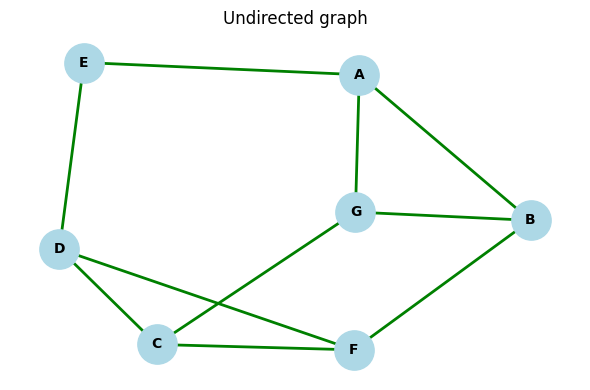

In [3]:
edges_list = [
        ('A', 'B', 4),#start_node -> end_node, weight(distance/strength of connection/time/capacity/etc. )
        ('C', 'D', 6),
        ('E', 'D', 4),
        ('A', 'E', 5),
        ('G', 'B', 7),
        ('F', 'D', 4),
        ('A', 'G', 5),
        ('C', 'G', 5),
        ('F', 'B', 5),
        ('C', 'F', 3)
]
graph_from_edges(edges_list)

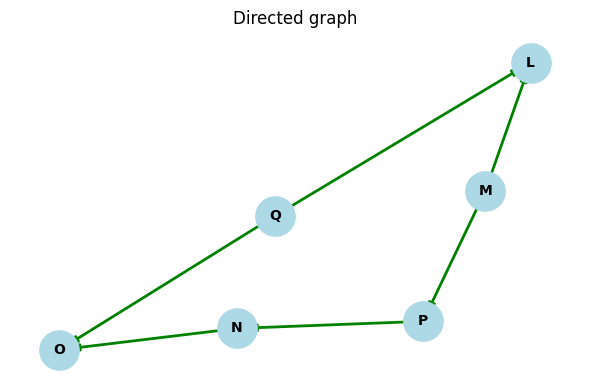

In [4]:
directed_edges = [
    ("P", "N", 3),
    ("Q", "O", 4),
    ("M", "P", 2),
    ("N", "O", 4),
    ("Q", "L", 3),
    ("M", "L", 2)
]
graph_from_edges(directed_edges, directed=True)

### Terms and Explanations 
3. Laplacian in Graph Theory
   - **The Graph Laplacian** is a matrix representation that encodes the stucture of a graph
   - It is widely used in analyzing connectivity, spectral properties, and diffusion properties
     $$ G = (V, E);$$
         - a simple graph (no multiple edges or loops)
     $$V(G) = \{v_1, \dots, v_n\} \text{ - vertex set with } n = |V|$$
     $$E(G) = e_{ij} \text{ - edge set with } m = |E|$$
         - An edge $e_{ij}$ connects vertices $v_i$ and $v_j$ if they are adjacent (or neighbours). Adjacency can be notated as $v_i \sim v_j$
     $$ [L = D - A]$$
     where:
     $$ L - \text{Laplacian}$$
     $$ D - \text{degree matrix (diagonal entries are vertex degrees/degree of each vertex on the diagonal)} $$
     $$
     D =
     \begin{pmatrix}
     d(v_1) & 0 & \cdots & 0 \\
     0 & d(v_2) & \cdots & 0 \\
     \vdots & \vdots & \ddots & \vdots \\
     0 & 0 & \cdots & d(v_n)
     \end{pmatrix} 
     $$
     $$ A - \text{adjacency matrix (entries indicate edge connections/connections between vertices)}$$



     $$
     A_{ij} :=
     \begin{cases}
     1 & \text{if there's an edge } e_{ij} \\
     0 & \text{if there's no edge} \\
     i = j
     \end{cases}
     $$
  
     $$ A =
        \begin{pmatrix}
        0 & 1 & 0 \\
        1 & 0 & 1 \\
        0 & 1 & 0
        \end{pmatrix}
     $$
     
     $A_{ii}; \space i = j$ - the diagonal of the matrix.
     
     It represents whether vertex $v_i$ has an edge to itself, called a self-loop.
     
     Simple graphs do not allow self-loops or multiple edges.
     
     1. Degree of $v$ - numbers of neighbours of a node, denoted by:
     $$ d(v), d(v_i) = \sum_{v_i \sim v_j} e_{ij}$$
     The Laplacian measures the differences between nodes and their neighbours:
     $$ (Lx)_i = d(v)_i x_i - \sum_{v_j \sim v_i} x_j $$
     which equals
     $$ (Lx)_i = \sum_{v_j \sim v_i} (x_i - x_j) $$
     It measures how different vertex $i$ is from its neighbours

     3. Regular graph - all the nodes have the same degree; example:
        - **Eulerian graph** - Contains an Eulerian circuit (a closed path that visits every edge exactly once); It's used in network design and routing problems
     4. Complete graph - has an edge between every pair of vertices

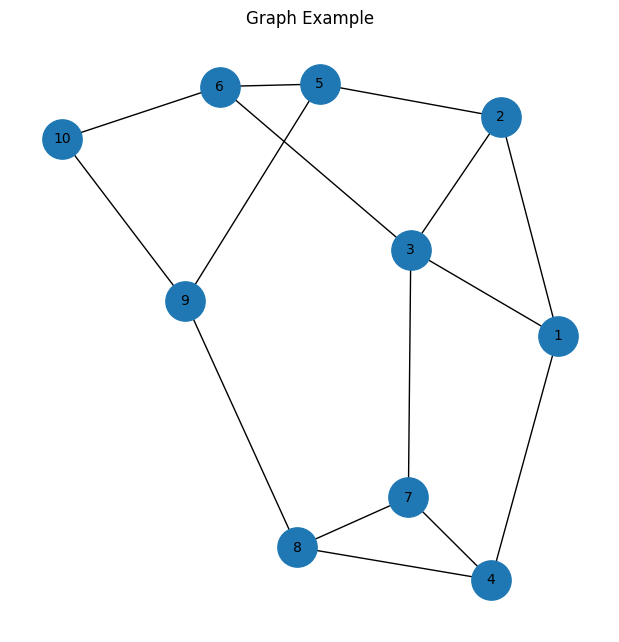

Adjacency Matrix A:
[[0 1 1 1 0 0 0 0 0 0]
 [1 0 1 0 1 0 0 0 0 0]
 [1 1 0 0 0 1 1 0 0 0]
 [1 0 0 0 0 0 1 1 0 0]
 [0 1 0 0 0 1 0 0 1 0]
 [0 0 1 0 1 0 0 0 0 1]
 [0 0 1 1 0 0 0 1 0 0]
 [0 0 0 1 0 0 1 0 1 0]
 [0 0 0 0 1 0 0 1 0 1]
 [0 0 0 0 0 1 0 0 1 0]]

Degree Matrix D:
[[3 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0]
 [0 0 4 0 0 0 0 0 0 0]
 [0 0 0 3 0 0 0 0 0 0]
 [0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 3 0 0 0]
 [0 0 0 0 0 0 0 3 0 0]
 [0 0 0 0 0 0 0 0 3 0]
 [0 0 0 0 0 0 0 0 0 2]]

Laplacian Matrix L = D - A:
[[ 3 -1 -1 -1  0  0  0  0  0  0]
 [-1  3 -1  0 -1  0  0  0  0  0]
 [-1 -1  4  0  0 -1 -1  0  0  0]
 [-1  0  0  3  0  0 -1 -1  0  0]
 [ 0 -1  0  0  3 -1  0  0 -1  0]
 [ 0  0 -1  0 -1  3  0  0  0 -1]
 [ 0  0 -1 -1  0  0  3 -1  0  0]
 [ 0  0  0 -1  0  0 -1  3 -1  0]
 [ 0  0  0  0 -1  0  0 -1  3 -1]
 [ 0  0  0  0  0 -1  0  0 -1  2]]


In [5]:
G = nx.Graph()

edges = [
    (1,2),(1,3),(1,4),
    (2,3),(2,5),
    (3,6),(3,7),
    (4,7),(4,8),
    (5,6),(5,9),
    (6,10),
    (7,8),
    (8,9),
    (9,10)
]

G.add_edges_from(edges)

plt.figure(figsize=(6,6))
pos = nx.spring_layout(G) 
nx.draw(G, pos, with_labels=True, node_size=800, font_size=10)
plt.title("Graph Example")
plt.show()

A = nx.adjacency_matrix(G).todense()

# Degree Matrix
degrees = [d for n, d in G.degree()]
D = np.diag(degrees)

# Laplacian
L = D - A

print("Adjacency Matrix A:")
print(A)

print("\nDegree Matrix D:")
print(D)

print("\nLaplacian Matrix L = D - A:")
print(L)

The graph is Eulerian
Eulerian circuit: [(0, 5), (5, 4), (4, 3), (3, 2), (2, 1), (1, 0)]


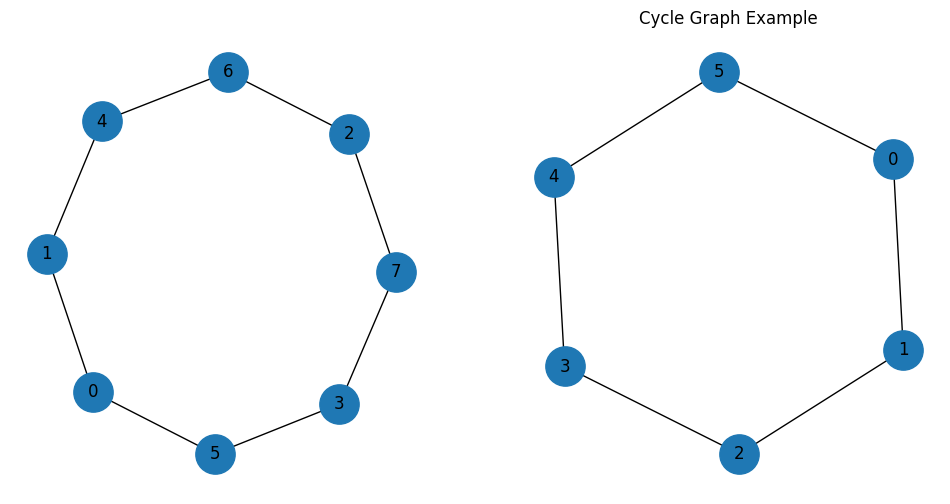

In [19]:
#an Eulerian Graph example:
G = nx.random_regular_graph(d=2, n=8)#the shortest way

Q = nx.cycle_graph(6)#6 nodes
if nx.is_eulerian(Q):
    circuit = list(nx.eulerian_circuit(Q))
    print(f'The graph is Eulerian.\n'
          f'Eulerian circuit: {circuit}')
else:
    print('The graph is not Eulerian')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

pos_G = nx.spring_layout(G) 
nx.draw(G, pos_G, with_labels=True, node_size=800, font_size=12, ax=axes[0])
plt.title("Random Regular Graph Example")

pos_Q = nx.spring_layout(Q, seed=42) 
nx.draw(Q, pos_Q, with_labels=True, node_size=800, font_size=12, ax=axes[1])
plt.title("Cycle Graph Example")

plt.show()

In [6]:
#### Legend (#TO-DO)
import sys
print(sys.executable)

C:\Users\Dell-User\jupyter_projects\final_project\osmnx_venv\Scripts\python.exe
